In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.pipeline.props_pipeline.apm_pipeline import apm_pipeline
from src.features.feature_engineer.apm_features import apm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
140,2025-26,1630598,Aaron Wiggins,Aaron,1610612760,OKC,Oklahoma City Thunder,22501155,2026-04-07T00:00:00,OKC @ LAL,W,19.950000,4,7,0.571,2,4,0.500,0,0,0.0,0,2,2,0,1,1,0,0,2,0,10,4,14.4,0,0,16.0,1,19:57,1,109.7,111.6,111.6,103.3,102.3,102.3,6.4,9.3,9.3,0.000,0.00,0.0,0.000,0.091,0.044,12.5,12.5,0.714,0.714,0.163,0.168,103.89,103.46,86.22,103.46,0.077,43,4.0,7.0,45,89,0.506,21,41,0.512,12,14,0.857,10,36,46,29,12.0,15,2,3,21,12,123,36.0,126.6,128.1,91.0,89.7,35.6,38.4,0.644,2.42,21.2,0.273,0.776,0.538,0.125,0.624,0.646,96.4,96.5,80.42,96,0.655,1610612747,LAL,Los Angeles Lakers,32,73,0.438,9,26,0.346,14,31,0.452,8,30,38,26,17.0,7,3,2,12,21,87,-36.0,91.0,89.7,126.6,128.1,-35.6,-38.4,0.813,1.53,19.4,0.224,0.727,0.462,0.175,0.500,0.502,96.4,96.5,80.42,97,0.345,NaN,SG,27.0,0
139,2025-26,1642347,Jamal Shead,Jamal,1610612761,TOR,Toronto Raptors,22501151,2026-04-07T00:00:00,TOR vs. MIA,W,23.560000,1,4,0.250,1,3,0.333,0,0,0.0,0,1,1,11,3,0,0,0,2,1,3,27,17.7,0,0,16.0,1,23:34,1,129.4,128.0,128.0,71.6,71.2,71.2,57.8,56.8,56.8,0.423,3.67,61.1,0.000,0.031,0.018,16.7,16.7,0.375,0.375,0.119,0.122,102.97,103.90,86.59,103.90,0.071,50,1.0,4.0,49,99,0.495,12,28,0.429,11,16,0.688,15,41,56,34,12.0,9,5,3,19,15,121,26.0,117.4,118.6,91.0,93.1,26.4,25.5,0.694,2.83,22.2,0.315,0.759,0.545,0.118,0.556,0.571,103.7,102.0,85.00,102,0.634,1610612748,MIA,Miami Heat,33,91,0.363,12,44,0.273,17,19,0.895,10,34,44,26,15.0,3,3,5,15,19,95,-26.0,91.0,93.1,117.4,118.6,-26.4,-25.5,0.788,1.73,18.3,0.241,0.685,0.455,0.147,0.429,0.478,103.7,102.0,85.00,102,0.366,NaN,PG,23.0,0
138,2025-26,203914,Gary Harris,Gary,1610612749,MIL,Milwaukee Bucks,22501150,2026-04-07T00:00:00,MIL @ BKN,L,21.101667,3,9,0.333,1,4,0.250,0,0,0.0,1,2,3,1,0,0,2,1,1,1,7,-11,18.1,0,0,16.0,1,21:06,1,80.0,77.8,77.8,105.7,104.5,104.5,-25.7,-26.8,-26.8,0.100,0.00,10.0,0.043,0.105,0.071,0.0,0.0,0.389,0.389,0.170,0.185,99.27,101.22,84.35,101.22,0.069,45,3.0,9.0,35,81,0.432,15,45,0.333,5,8,0.625,9,35,44,25,20.0,6,7,4,20,13,90,-6.0,94.2,96.8,99.9,103.2,-5.7,-6.5,0.714,1.25,18.8,0.313,0.814,0.549,0.215,0.525,0.532,95.8,93.0,77.50,93,0.464,1610612751,BKN,Brooklyn Nets,33,75,0.440,9,26,0.346,21,23,0.913,3,29,32,18,14.0,11,4,7,13,20,96,6.0,99.9,103.2,94.2,96.8,5.7,6.5,0.545,1.29,15.1,0.186,0.688,0.451,0.151,0.500,0.564,95.8,93.0,77.50,93,0.536,NaN,SG,31.0,0
149,2025-26,1642967,John Poulakidas,John,1610612742,DAL,Dallas Mavericks,22501

In [3]:
def apply_bayesian_apm(df, confidence_k=20, min_minutes=1.0):
    """
    Shrink player PTS/MIN toward a (pos, STARTING) role prior.
    confidence_k: pseudo sample size for the prior (same interpretation as minutes).
    min_minutes: only rows with MIN >= this contribute to PPM (avoids divide-by-zero).
    """
    df = df.copy()
    df["_ppm"] = np.where(df["MIN"] >= min_minutes, df["AST"] / df["MIN"], np.nan)

    priors = df.groupby(["pos", "STARTING"], dropna=False)["_ppm"].mean().to_dict()

    player_stats = df.groupby("PLAYER_ID", as_index=False).agg(
        player_mean_ppm=("_ppm", "mean"),
        games_played=("_ppm", "count"),
    )

    df = df.merge(player_stats, on="PLAYER_ID", how="left")

    def _prior_for_row(row):
        key = (row["pos"], row["STARTING"])
        v = priors.get(key)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return float(df["_ppm"].mean())
        return float(v)

    df["prior_ppm"] = df.apply(_prior_for_row, axis=1)

    df["bayesian_ppm_proj"] = (
        (df["games_played"] * df["player_mean_ppm"]) + (confidence_k * df["prior_ppm"])
    ) / (df["games_played"] + confidence_k)

    df["bayesian_ppm_proj"] = df["bayesian_ppm_proj"].round(4)
    df = df.drop(columns=["_ppm"], errors="ignore")

    return df["bayesian_ppm_proj"]

In [5]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["AST_PER_MIN"] = df["AST"] / df["MIN"].replace(0, np.nan)
    df["TOV_PER_MIN"] = df["TOV"] / df["MIN"].replace(0, np.nan)
    df['BAYES_APM_PROJ'] = apply_bayesian_apm(df)
    df = apm_features(df)
    df['TEAM_USG_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_AST_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['AST_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_AST_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['AST_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['MEDIAN_AST_PER_MIN_L10'] = (df.groupby('PLAYER_ID')['AST_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
    df["AST_ewm3"] = df.groupby("PLAYER_ID")["AST"].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
    df['AST_ewm5'] = (df.groupby('PLAYER_ID')['AST'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['AST_ewm10'] = (df.groupby('PLAYER_ID')['AST'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['AST_PER_MIN_ewm10'] = (df.groupby('PLAYER_ID')['AST_PER_MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm5'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_ewm3'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean()))
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])
    df["BLOWOUT_RISK"] = df.groupby("PLAYER_ID")["TEAM_PLUS_MINUS"].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).std())
    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 12).mean())
    eligible = player_avgs[player_avgs >= 0.60].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.to_csv('data/processed/training/S26_TRAINING_APM.csv', index=False)

(83728, 254)


In [6]:
APM_FEATURES = [
    'BAYES_APM_PROJ',
    'AST_PCT_roll5',
    'AST_RATIO_roll5',
    'AST_TO_roll5',
    'MEDIAN_AST_PER_MIN_L10', #new
    'USG_PCT_roll5',
    'MIN_ewm10',
    'AST_PER_MIN_ewm10',
    'AST_PER_MIN_roll5',
    'TEAM_AST_PER_MIN_RANK_L10',
    'TEAM_AST_PER_MIN_RANK_L5',
    'TEAM_USG_RANK_L5',
    'AST_share_proxy_roll5',
    'MIN_share_proxy',
    'TEAM_POSS_share_roll5',
    'OPP_PACE_roll5',
    'OPP_POSS_roll5',
    'OPP_DEF_RATING_roll5',
    'DAYS_REST',
    'IS_B2B',
    'STARTING',
    'GP',
    'POSITION_ENC',
]


In [7]:
ppm_df = df[APM_FEATURES + ["AST_PER_MIN", "MIN", "GAME_DATE"]].dropna()

split_date = ppm_df["GAME_DATE"].quantile(0.75)
train_mask = ppm_df["GAME_DATE"] <= split_date
val_mask = ~train_mask

X_train_ppm = ppm_df.loc[train_mask, APM_FEATURES]
y_train_ppm = ppm_df.loc[train_mask, "AST_PER_MIN"]
X_val_ppm   = ppm_df.loc[val_mask, APM_FEATURES]
y_val_ppm   = ppm_df.loc[val_mask, "AST_PER_MIN"]

quantiles = [0.10, 0.50, 0.90]
quantile_models = {}
quantile_preds = {}

for q in quantiles:
    q_float = float(q)
    key = f"q_{q_float:.2f}"
    print(f"Training model for Quantile: {key}...")

    xgb_q = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q_float,
        n_estimators=800,
        max_depth=8,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        learning_rate=0.01,
        reg_lambda=0.1,
        reg_alpha=0.1,
        random_state=42,
        n_jobs=-1,
    )

    xgb_q.fit(
        X_train_ppm,
        y_train_ppm,
        eval_set=[(X_val_ppm, y_val_ppm)],
        verbose=False,
    )

    quantile_models[key] = xgb_q
    quantile_preds[key] = xgb_q.predict(X_val_ppm)

results_df = X_val_ppm.copy()
results_df["Actual"] = y_val_ppm.values
results_df["Lower_10"] = quantile_preds["q_0.10"]
results_df["Median_50"] = quantile_preds["q_0.50"]
results_df["Upper_90"] = quantile_preds["q_0.90"]
results_df["MIN"] = ppm_df.loc[val_mask, "MIN"].values

# Optional: high-minute slice for diagnostics (PPM vs actual PTS/min when MIN >= 35)
high_min_stars = results_df[results_df["MIN"] >= 35]

print("\n--- Val rows with Actual MIN >= 35 (PPM model, target = AST_PER_MIN) ---")
print(f"Average Actual AST/MIN: {high_min_stars['Actual'].mean():.3f}")
print(f"Avg Median Pred AST/MIN: {high_min_stars['Median_50'].mean():.3f}")

q50_mae = mean_absolute_error(y_val_ppm, quantile_preds["q_0.50"])
q50_rmse = np.sqrt(mean_squared_error(y_val_ppm, quantile_preds["q_0.50"]))
q50_r2 = r2_score(y_val_ppm, quantile_preds["q_0.50"])

print(f"\n[Overall Median Model] MAE: {q50_mae:.3f} PTS/min")
print(f"RMSE: {q50_rmse:.3f} PTS/min")
print(f"R-squared: {q50_r2:.2f}")

Training model for Quantile: q_0.10...
Training model for Quantile: q_0.50...
Training model for Quantile: q_0.90...

--- Val rows with Actual MIN >= 35 (PPM model, target = AST_PER_MIN) ---
Average Actual AST/MIN: 0.133
Avg Median Pred AST/MIN: 0.129

[Overall Median Model] MAE: 0.054 PTS/min
RMSE: 0.074 PTS/min
R-squared: 0.36


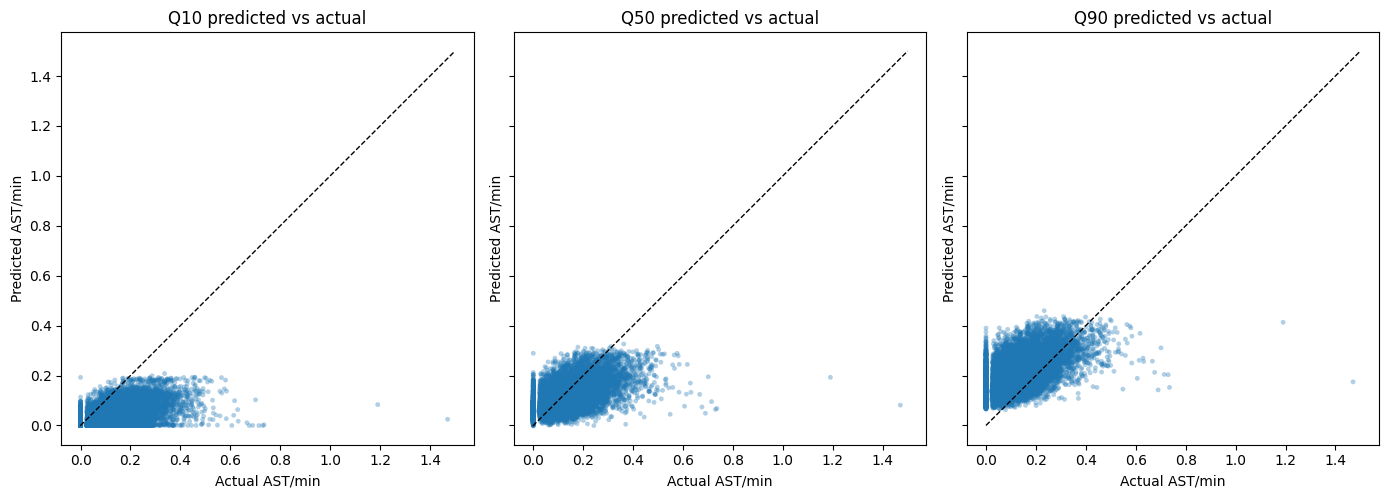

Q10 P(y ≤ pred): 0.13139196272568435
Q50 P(y ≤ pred): 0.5036109493302271
Q90 P(y ≤ pred): 0.889341875364007
Coverage (10–90 interval): 75.79%


In [8]:
import matplotlib.pyplot as plt

y_true = y_val_ppm
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual AST/min")
    ax.set_ylabel("Predicted AST/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%

In [9]:
# Use quantile regression to get a range instead of a single number
from sklearn.ensemble import GradientBoostingRegressor

lower = GradientBoostingRegressor(loss='quantile', alpha=0.1)
upper = GradientBoostingRegressor(loss='quantile', alpha=0.9)
mid   = GradientBoostingRegressor(loss='quantile', alpha=0.5)

lower.fit(X_train_ppm, y_train_ppm)
upper.fit(X_train_ppm, y_train_ppm)
mid.fit(X_train_ppm, y_train_ppm)

pred_low  = lower.predict(X_val_ppm)
pred_high = upper.predict(X_val_ppm)
pred_mid  = mid.predict(X_val_ppm)

# Coverage — what % of actuals fall within the interval?
coverage = ((y_val_ppm >= pred_low) & (y_val_ppm <= pred_high)).mean()
print(f"Coverage: {coverage:.2%}")  # want this close to 80%

Coverage: 89.74%


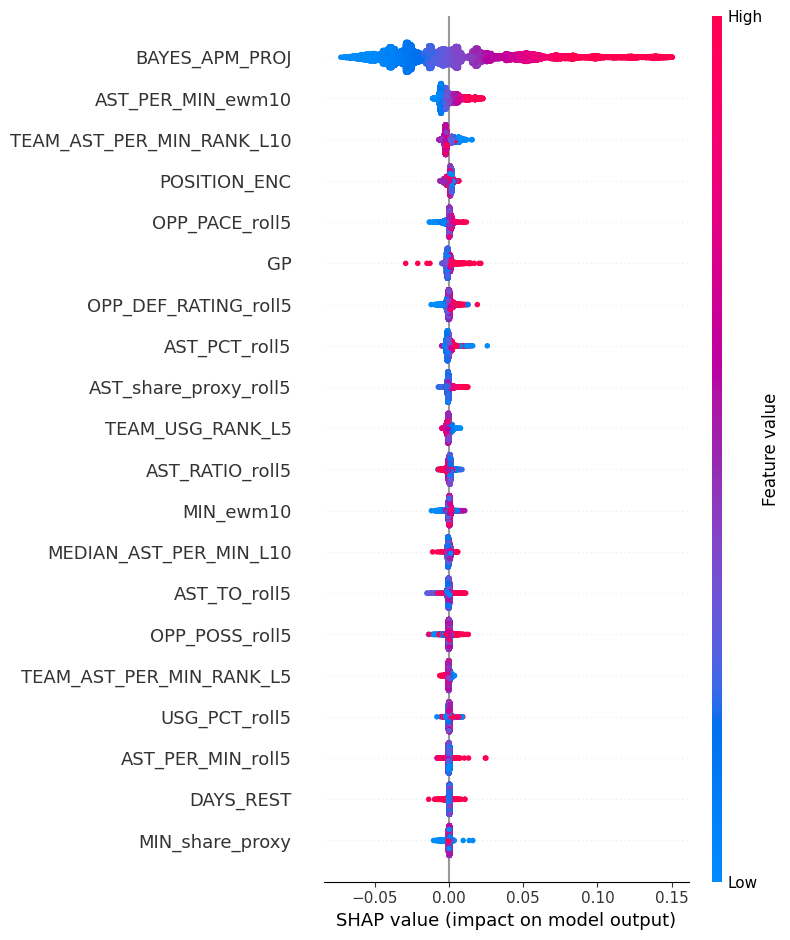

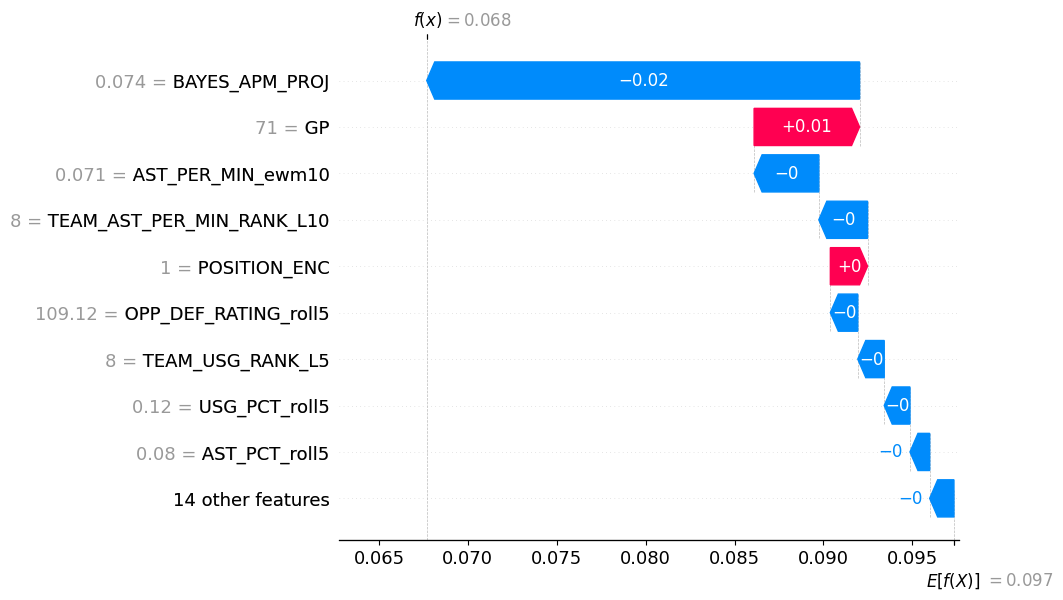

In [10]:
import shap

model = quantile_models["q_0.50"]   
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_ppm)
shap.summary_plot(shap_values, X_val_ppm, feature_names=APM_FEATURES)
shap.plots.waterfall(shap_values[1154])

In [11]:
import joblib
from pathlib import Path

out_dir = Path("apm_quantile")  # or wherever you prefer
out_dir.mkdir(parents=True, exist_ok=True)

bundle = {
    "quantile_models": quantile_models,
    "feature_names": APM_FEATURES,  # or list(X_train_min.columns)
}
joblib.dump(bundle, "src/models/saved_models/apm_quantile_xgb.joblib")

['src/models/saved_models/apm_quantile_xgb.joblib']

In [12]:
from src.utils.scrap_starters import NBADailyLineups

scraper = NBADailyLineups("https://www.rotowire.com/basketball/nba-lineups.php")
scraper.getDict()  # Scrape the lineups
print("\nQuestionable Players:")
print(scraper.getQuestionablePlayers())
print("\nOut Players:")
print(scraper.getOutPlayers())
outPlayers = scraper.getOutPlayers()
scraper.updateTeamInfo()  # Update teamInfo.py


Questionable Players:
{'MIA': ['Dru Smith'], 'IND': ['Ben Sheppard', 'Kobe Brown', 'Jarace Walker'], 'BOS': ['Neemias Queta', 'Derrick White'], 'NYK': ['Tyler Kolek'], 'HOU': ['Tari Eason'], 'LAL': ['Marcus Smart'], 'GSW': ['Charles Bassey', 'Stephen Curry', 'Gui Santos']}

Out Players:
{'CHI': ['Josh Giddey', 'Isaac Okoro', 'Nick Richards', 'Matas Buzelis', 'Anfernee Simons'], 'WAS': ['Tristan Vukcevic', 'Anthony Davis', 'Bilal Coulibaly', 'Alex Sarr', 'Trae Young', 'Jaden Hardy', "D'Angelo Russell", 'Tre Johnson'], 'MIA': ['Terry Rozier', 'Nikola Jović'], 'TOR': ['Trayce Jackson-Davis', 'Chucky Hepburn'], 'IND': ['Pascal Siakam', 'Andrew Nembhard', 'T.J. McConnell', 'Aaron Nesmith'], 'BKN': ['Nic Claxton', 'Nolan Traore', 'Ziaire Williams', 'Noah Clowney', 'Josh Minott', 'Terance Mann'], 'BOS': ['Jaylen Brown'], 'PHI': ['Johni Broome', 'Joel Embiid', 'Cameron Payne'], 'HOU': ['Fred VanVleet'], 'LAL': ['Jaxson Hayes', 'Austin Reaves', 'Luka Dončić'], 'GSW': ['Kristaps Porziņģis', 'Al

In [10]:
date = pd.Timestamp.now().normalize()  # midnight today, local tz
current_date = date.strftime("%Y-%m-%d")

# target_date = pd.Timestamp("2026-03-26")
# hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_assists')]
names = lines_dfs['NAME'].unique()
names

array(['Jalen Brunson', 'Mikal Bridges', 'Derrick White',
       'Payton Pritchard', 'Ousmane Dieng', 'Ace Bailey', 'Reed Sheppard',
       'Cody Williams', 'Scottie Barnes', 'Brandon Ingram',
       'DeMar DeRozan', 'Derik Queen', 'Devin Vassell', 'Aaron Gordon'],
      dtype=object)

In [11]:
import joblib

min_bundle = joblib.load("src/models/saved_models/min_quantile_xgb.joblib")
min_quantile_models = min_bundle["quantile_models"]
min_feature_names = min_bundle["feature_names"]

apm_bundle = joblib.load("src/models/saved_models/apm_quantile_xgb.joblib")
apm_quantile_models = apm_bundle["quantile_models"]
apm_feature_names = apm_bundle["feature_names"]

## MIN + APM (ANALYSIS)

In [12]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        apm_feats = apm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        ppm_arr = np.asarray(apm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(apm_quantile_models["q_0.10"].predict(ppm_arr)[0])
        p50 = float(apm_quantile_models["q_0.50"].predict(ppm_arr)[0])
        p90 = float(apm_quantile_models["q_0.90"].predict(ppm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_APM_Q10": p10,
            "PRED_APM_Q50": p50,
            "PRED_APM_Q90": p90,
            "PRED_AST_Q10": round(pts10, 2),
            "PRED_AST_Q50": round(pts50, 2),
            "PRED_AST_Q90": round(pts90, 2),
            "PRED_AST_RANGE_10_90": round(pts90 - pts10, 2),
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_APM_Q10": np.nan,
            "PRED_APM_Q50": np.nan,
            "PRED_APM_Q90": np.nan,
            "PRED_AST_Q10": np.nan,
            "PRED_AST_Q50": np.nan,
            "PRED_AST_Q90": np.nan,
            "PRED_AST_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_APM_Q10,PRED_APM_Q50,PRED_APM_Q90,PRED_AST_Q10,PRED_AST_Q50,PRED_AST_Q90,PRED_AST_RANGE_10_90
0,Jalen Brunson,28.122652,34.614182,40.191032,0.112316,0.209611,0.307936,3.16,7.26,12.38,9.22
1,Mikal Bridges,26.002607,31.541300,39.685745,0.061706,0.105951,0.186293,1.60,3.34,7.39,5.79
2,Derrick White,23.854902,32.782490,38.426723,0.083617,0.142021,0.244512,1.99,4.66,9.40,7.40
3,Payton Pritchard,19.423317,27.332935,34.415184,0.034707,0.138776,0.232168,0.67,3.79,7.99,7.32
4,Ousmane Dieng,16.411581,27.213976,35.196236,0.061346,0.145355,0.246298,1.01,3.96,8.67,7.66


In [13]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. THE CORE SIMULATION ENGINE (POISSON-BASED)
# ---------------------------------------------------------

def triangular_clip(row, q10, q50, q90, lo_scale=0.70, hi_scale=1.30, low=0.0, high=np.inf, n_sims=10_000):
    """
    Generates a triangular distribution based on XGBoost quantiles.
    Widening the scales (lo_scale, hi_scale) introduces 'NBA Chaos' (fouls, blowouts).
    """
    mode = float(row[q50])
    # Ensure left < mode < right
    left = min(float(row[q10]) * lo_scale, mode - 0.001)
    right = max(float(row[q90]) * hi_scale, mode + 0.001)
    
    if not (np.isfinite(left) and np.isfinite(mode) and np.isfinite(right)):
        return np.full(n_sims, mode if np.isfinite(mode) else 0.0)
    
    # Generate continuous samples
    samples = np.random.triangular(left, mode, right, size=n_sims)
    return np.clip(samples, low, high)

def run_stat_simulation(row, stat_prefix="APM", n_sims=10_000):
    """
    Paired simulation: Minutes * Rate.
    Converts expected continuous value into discrete integers using Poisson.
    """
    # Simulate Minutes
    sim_min = triangular_clip(
        row,
        "PRED_MIN_Q10", "PRED_MIN_Q50", "PRED_MIN_Q90",
        lo_scale=0.75, hi_scale=1.25, low=0, high=48, n_sims=n_sims,
    )
    
    # Simulate Rate (APM or RPM)
    sim_rate = triangular_clip(
        row,
        f"PRED_{stat_prefix}_Q10", f"PRED_{stat_prefix}_Q50", f"PRED_{stat_prefix}_Q90",
        lo_scale=0.70, hi_scale=1.30, low=0, high=np.inf, n_sims=n_sims,
    )
    
    # Calculate Lambda (Expected value for each sim)
    expected_val = sim_min * sim_rate
    
    # Poisson Sampling: The 'Counting' Step
    # This turns 7.4 expected rebounds into a distribution of 6, 7, 8, 9...
    sim_counts = np.random.poisson(lam=expected_val)
    
    return sim_counts

# ---------------------------------------------------------
# 2. LINE LOOKUP & MAPPING
# ---------------------------------------------------------

def _line_lookup_from_lines_df(ldf: pd.DataFrame, name_dict: dict) -> dict:
    """
    Maps sportsbook names to canonical dataset names.
    Handles 'Jokic' vs 'Jokić' logic.
    """
    d = {}
    for _, r in ldf.iterrows():
        book_name = str(r["NAME"]).strip()
        line = r["LINE"]
        d[book_name] = line
        
        # Add the canonical version if it exists in your nameDict
        canon = name_dict.get(book_name)
        if canon:
            d[canon] = line
            
    # Reverse check: ensure variants point to the line if canon was found
    for variant, canon in name_dict.items():
        if canon in d and variant not in d:
            d[variant] = d[canon]
    return d

# ---------------------------------------------------------
# 3. EXECUTION LOOP
# ---------------------------------------------------------

# Build the lookup
line_by_name = _line_lookup_from_lines_df(lines_dfs, nameDict)

results = []
for _, row in preds_df.iterrows():
    name = row["PLAYER_NAME"]
    line = line_by_name.get(name)
    
    # Validation
    if line is None or np.isnan(row.get("PRED_MIN_Q50", np.nan)):
        results.append({
            "PLAYER_NAME": name, "LINE": np.nan, 
            "P_OVER": np.nan, "P_UNDER": np.nan, "P_PUSH": np.nan
        })
        continue

    # Run the Poisson Simulation (Change prefix to 'APM' for Assists)
    stat_sims = run_stat_simulation(row, stat_prefix="APM", n_sims=10_000)
    line = float(line)
    
    # Calculate Integer-Aware Probabilities
    p_over = float(np.mean(stat_sims > line))
    p_under = float(np.mean(stat_sims < line))
    p_push = float(np.mean(stat_sims == line))

    # Calculate Edge and EV
    # Assuming -119 odds (~1.84x payout) for Underdog standard
    # EV = (P_win * Profit) - (P_loss * Stake)
    # Simplified here for relative ranking:
    edge = row["PRED_AST_Q50"] - line 
    
    results.append({
        "PLAYER_NAME": name,
        "LINE": line,
        "PRED_MIN_Q50": round(row["PRED_MIN_Q50"], 2), 
        "PRED_STAT_Q50": round(row["PRED_AST_Q50"], 2),
        "P_OVER": round(p_over, 3), 
        "P_UNDER": round(p_under, 3),
        "P_PUSH": round(p_push, 3),
        "EDGE": round(edge, 2),
        "EV": round((p_over * 10) - (p_under * 10), 2) # Weighted directional EV
    })

# Create final DataFrame
line_probs_df = pd.DataFrame(results)

# Sort by absolute edge to find the biggest discrepancies
line_probs_df['ABS_EDGE'] = line_probs_df['EDGE'].abs()
line_probs_df = line_probs_df.sort_values(by="ABS_EDGE", ascending=False)

# Display top plays
print(line_probs_df[['PLAYER_NAME', 'LINE', 'PRED_STAT_Q50', 'P_OVER', 'P_UNDER', 'P_PUSH', 'EDGE']].head(15))

         PLAYER_NAME  LINE  PRED_STAT_Q50  P_OVER  P_UNDER  P_PUSH  EDGE
8     Scottie Barnes   8.5           7.28   0.417    0.583     0.0 -1.22
5         Ace Bailey   2.5           1.59   0.375    0.625     0.0 -0.91
6      Reed Sheppard   4.5           3.78   0.457    0.543     0.0 -0.72
7      Cody Williams   3.5           2.78   0.403    0.597     0.0 -0.72
3   Payton Pritchard   4.5           3.79   0.422    0.578     0.0 -0.71
10     DeMar DeRozan   4.5           5.18   0.646    0.354     0.0  0.68
4      Ousmane Dieng   4.5           3.96   0.463    0.537     0.0 -0.54
9     Brandon Ingram   3.5           3.99   0.669    0.331     0.0  0.49
13      Aaron Gordon   2.5           2.88   0.680    0.320     0.0  0.38
12     Devin Vassell   2.5           2.83   0.691    0.309     0.0  0.33
0      Jalen Brunson   7.5           7.26   0.524    0.476     0.0 -0.24
1      Mikal Bridges   3.5           3.34   0.581    0.419     0.0 -0.16
2      Derrick White   4.5           4.66   0.603  